# 06 — FPN Training

**Project:** BraTS-PEDs glioma segmentation  
**Model:** 2D FPN · ResNet34 encoder · ImageNet pretrained  
**Loss:** Combined Dice + Focal  
**Optimiser:** AdamW + CosineAnnealingLR  

### Two-phase training strategy
| Phase | Encoder | Epochs | Rationale |
|---|---|---|---|
| 1 — Warm-up | **Frozen** | 5 | Prevents destroying ImageNet weights while decoder is random |
| 2 — Fine-tune | **Unfrozen** | remaining | Full end-to-end optimisation |

### Input contract
- Pre-extracted `.npy` slices in `processed_dataset/`
- Image shape: `[4, 240, 240]` · float32 · Z-score normalised
- Mask shape:  `[240, 240]` · int8  · labels {0,1,2,3}
- Center-cropped to **192×192** before forwarding

---

## 1 — Imports & reproducibility

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import DataLoader

# Add project root to path so `src` is importable
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import BraTSDataset
from src.losses import CombinedLoss
from src.train_utils import (
    get_augmentation,
    get_class_weights,
    train_one_epoch,
    evaluate,
    set_encoder_trainable,
    save_checkpoint,
    load_checkpoint,
    format_metrics,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"SMP      : {smp.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

PyTorch  : 2.11.0+cu128
SMP      : 0.5.0
CUDA     : True


## 2 — Configuration

In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
DATA_DIR   = PROJECT_ROOT / "processed_dataset"
CKPT_DIR   = PROJECT_ROOT / "checkpoints" / "fpn"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT  = str(CKPT_DIR / "best.pth")
LAST_CKPT  = str(CKPT_DIR / "last.pth")

# ── Model ───────────────────────────────────────────────────────────────────
ENCODER      = "resnet34"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES  = 4          # 0=BG, 1=NCR, 2=ED, 3=ET
IN_CHANNELS  = 4          # t1c, t1n, t2f, t2w
CROP_SIZE    = 192

# ── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE        = 16
NUM_WORKERS       = 4
PIN_MEMORY        = True

PHASE1_EPOCHS     = 5     # encoder frozen
PHASE2_EPOCHS     = 25    # full fine-tuning
TOTAL_EPOCHS      = PHASE1_EPOCHS + PHASE2_EPOCHS

LR_PHASE1         = 3e-4  # higher LR: only decoder is trained
LR_PHASE2         = 1e-4  # lower LR: full model, prevent catastrophic forgetting
WEIGHT_DECAY      = 1e-4

# ── Loss ────────────────────────────────────────────────────────────────────
DICE_WEIGHT       = 1.0
FOCAL_WEIGHT      = 1.0
FOCAL_GAMMA       = 2.0
IGNORE_BACKGROUND = True  # exclude class-0 from Dice average

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── AMP (mixed precision) ───────────────────────────────────────────────────
USE_AMP = DEVICE.type == "cuda"

print(f"Device   : {DEVICE}")
print(f"AMP      : {USE_AMP}")
print(f"Crop     : {CROP_SIZE}x{CROP_SIZE}")
print(f"Epochs   : {PHASE1_EPOCHS} (frozen) + {PHASE2_EPOCHS} (fine-tune) = {TOTAL_EPOCHS}")
print(f"Checkpoints -> {CKPT_DIR}")

Device   : cuda
AMP      : True
Crop     : 192x192
Epochs   : 5 (frozen) + 25 (fine-tune) = 30
Checkpoints -> C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\fpn


## Pre-flight Sanity Check

Three independent tests — each prints **PASS** or **FAIL**.

In [3]:
import traceback
from src.train_utils import center_crop

_PASS = "  PASS"
_FAIL = "  FAIL"
_all_passed = True

DEVICE = torch.device("cuda")
USE_AMP = True

# TEST 1 — Hardware
print("=" * 60)
print("TEST 1 — Hardware / CUDA")
print("=" * 60)
try:
    assert torch.cuda.is_available(), "CUDA not available"
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(_PASS)
except Exception as e:
    print(f"  Error: {e}")
    print(_FAIL); _all_passed = False

# TEST 2 — DataLoader
print("\n" + "=" * 60)
print("TEST 2 — DataLoader")
print("=" * 60)
_batch_images = None
try:
    _ds = BraTSDataset(str(DATA_DIR / "train"), augment=get_augmentation(p=0.5))
    _loader = DataLoader(_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    _batch_images, _batch_masks = next(iter(_loader))
    print(f"  images: {tuple(_batch_images.shape)}, dtype: {_batch_images.dtype}")
    print(f"  masks:  {tuple(_batch_masks.shape)}, dtype: {_batch_masks.dtype}")
    print(_PASS)
except Exception as e:
    traceback.print_exc(); print(_FAIL); _all_passed = False

# TEST 3 — Forward + Backward (FPN)
print("\n" + "=" * 60)
print("TEST 3 — Forward pass + loss + backward (FPN)")
print("=" * 60)
try:
    assert _batch_images is not None
    _m = smp.FPN(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS,
                 in_channels=IN_CHANNELS, classes=NUM_CLASSES, activation=None).to(DEVICE)
    _c = CombinedLoss(num_classes=NUM_CLASSES, dice_weight=DICE_WEIGHT,
                      focal_weight=FOCAL_WEIGHT, gamma=FOCAL_GAMMA,
                      ignore_background=IGNORE_BACKGROUND,
                      class_weights=get_class_weights(device="cpu").tolist()).to(DEVICE)
    _o = torch.optim.AdamW(_m.parameters(), lr=LR_PHASE1, weight_decay=WEIGHT_DECAY)
    _imgs, _msks = center_crop(_batch_images.to(DEVICE), _batch_masks.to(DEVICE), CROP_SIZE)
    _o.zero_grad(set_to_none=True)
    _logits = _m(_imgs)
    _total, _d, _f = _c(_logits, _msks)
    print(f"  Logits: {tuple(_logits.shape)}")
    print(f"  Loss: {_total.item():.6f} (dice={_d.item():.4f} focal={_f.item():.4f})")
    _total.backward()
    _gn = torch.nn.utils.clip_grad_norm_(_m.parameters(), max_norm=1e9)
    assert torch.isfinite(_gn)
    print(f"  Grad norm: {_gn.item():.4f} (finite)")
    _o.step()
    print(_PASS)
    del _m, _c, _o, _logits; torch.cuda.empty_cache()
except Exception as e:
    traceback.print_exc(); print(_FAIL); _all_passed = False

print("\n" + "=" * 60)
if _all_passed:
    print("ALL TESTS PASSED")
else:
    print("TESTS FAILED — fix errors above")
print("=" * 60)

TEST 1 — Hardware / CUDA
  GPU: NVIDIA GeForce RTX 3080 Laptop GPU
  VRAM: 8.00 GB
  PASS

TEST 2 — DataLoader
  images: (16, 4, 240, 240), dtype: torch.float32
  masks:  (16, 240, 240), dtype: torch.int64
  PASS

TEST 3 — Forward pass + loss + backward (FPN)
  Logits: (16, 4, 192, 192)
  Loss: 1.006474 (dice=0.9927 focal=0.0138)
  Grad norm: 0.5740 (finite)
  PASS

ALL TESTS PASSED


## 3 — Datasets & DataLoaders

In [4]:
augment = get_augmentation(p=0.5)

train_ds = BraTSDataset(str(DATA_DIR / "train"), augment=augment)
val_ds   = BraTSDataset(str(DATA_DIR / "val"),   augment=None)
test_ds  = BraTSDataset(str(DATA_DIR / "test"),  augment=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train slices : {len(train_ds):>6,}  ->  {len(train_loader)} batches")
print(f"Val   slices : {len(val_ds):>6,}  ->  {len(val_loader)} batches")
print(f"Test  slices : {len(test_ds):>6,}  ->  {len(test_loader)} batches")

Train slices : 31,519  ->  1969 batches
Val   slices :  4,009  ->  251 batches
Test  slices :  4,010  ->  251 batches


## 4 — Model

In [5]:
model = smp.FPN(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    activation=None,
)
model = model.to(DEVICE)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = total_params - encoder_params

print(f"Model        : FPN / {ENCODER}")
print(f"Total params : {total_params:,}")
print(f"  Encoder    : {encoder_params:,}")
print(f"  Decoder    : {decoder_params:,}")

Model        : FPN / resnet34
Total params : 23,158,916
  Encoder    : 21,287,808
  Decoder    : 1,871,108


## 5 — Loss function & class weights

In [6]:
class_weights = get_class_weights(device=DEVICE)

print("Per-class weights (inverse-frequency, sum=1):")
for i, (name, w) in enumerate(zip(["BG", "NCR", "ED", "ET"], class_weights.tolist())):
    print(f"  class {i} ({name:3s}): {w:.6f}")

criterion = CombinedLoss(
    num_classes=NUM_CLASSES,
    dice_weight=DICE_WEIGHT,
    focal_weight=FOCAL_WEIGHT,
    gamma=FOCAL_GAMMA,
    ignore_background=IGNORE_BACKGROUND,
    class_weights=class_weights.cpu().tolist(),
).to(DEVICE)

Per-class weights (inverse-frequency, sum=1):
  class 0 (BG ): 0.000354
  class 1 (NCR): 0.533162
  class 2 (ED ): 0.079794
  class 3 (ET ): 0.386690


## 6 — Phase 1: Frozen encoder warm-up

In [7]:
set_encoder_trainable(model, trainable=False)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR_PHASE1, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=LR_PHASE1 / 10)
scaler = torch.amp.GradScaler(enabled=USE_AMP)

print(f"Trainable params : {sum(p.numel() for p in trainable_params):,}")

[set_encoder_trainable] Encoder is now frozen (21,287,808 params).
Trainable params : 1,871,108


In [8]:
history = {"train": [], "val": []}
best_val_dice = -1.0

print("=" * 70)
print(f"PHASE 1 — Frozen encoder  ({PHASE1_EPOCHS} epochs, LR={LR_PHASE1})")
print("=" * 70)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    fg_dice = np.mean([val_metrics["dice_NCR"], val_metrics["dice_ED"], val_metrics["dice_ET"]])

    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  <- best"
    else:
        tag = ""

    lr_now = scheduler.get_last_lr()[0]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, PHASE1_EPOCHS, val_metrics, scaler)
print(f"\nPhase 1 complete. Best fg Dice = {best_val_dice:.4f}")

PHASE 1 — Frozen encoder  (5 epochs, LR=0.0003)


  Epoch 01/30  loss=0.6290  val_loss=0.2159  fg_dice=0.7459  lr=2.74e-04  <- best


  Epoch 02/30  loss=0.2251  val_loss=0.2105  fg_dice=0.7474  lr=2.07e-04  <- best


  Epoch 03/30  loss=0.2083  val_loss=0.1804  fg_dice=0.7850  lr=1.23e-04  <- best


  Epoch 04/30  loss=0.1833  val_loss=0.1742  fg_dice=0.7885  lr=5.58e-05  <- best


  Epoch 05/30  loss=0.1735  val_loss=0.1734  fg_dice=0.7916  lr=3.00e-05  <- best

Phase 1 complete. Best fg Dice = 0.7916


## 7 — Phase 2: Full fine-tuning

Encoder is unfrozen. A fresh optimiser with a lower LR is created to prevent catastrophic forgetting.

In [9]:
set_encoder_trainable(model, trainable=True)

optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(),  "lr": LR_PHASE2 * 0.1},
        {"params": model.decoder.parameters(),  "lr": LR_PHASE2},
        {"params": model.segmentation_head.parameters(), "lr": LR_PHASE2},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=LR_PHASE2 / 100)

print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

[set_encoder_trainable] Encoder is now trainable (21,287,808 params).
Trainable params : 23,158,916


In [10]:
print("=" * 70)
print(f"PHASE 2 — Full fine-tuning  ({PHASE2_EPOCHS} epochs, LR={LR_PHASE2})")
print("=" * 70)

for epoch in range(PHASE1_EPOCHS + 1, TOTAL_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    fg_dice = np.mean([val_metrics["dice_NCR"], val_metrics["dice_ED"], val_metrics["dice_ET"]])

    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  <- best"
    else:
        tag = ""

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, TOTAL_EPOCHS, val_metrics, scaler)
print(f"\nTraining complete. Best val fg Dice = {best_val_dice:.4f}")
print(f"Best checkpoint  -> {BEST_CKPT}")
print(f"Last checkpoint  -> {LAST_CKPT}")

PHASE 2 — Full fine-tuning  (25 epochs, LR=0.0001)


  Epoch 06/30  loss=0.1567  val_loss=0.1389  fg_dice=0.8242  lr=9.96e-06  <- best


  Epoch 07/30  loss=0.1316  val_loss=0.1372  fg_dice=0.8268  lr=9.86e-06  <- best


  Epoch 08/30  loss=0.1186  val_loss=0.1265  fg_dice=0.8347  lr=9.68e-06  <- best


  Epoch 09/30  loss=0.1096  val_loss=0.1289  fg_dice=0.8334  lr=9.44e-06


...

  Epoch 26/30  loss=0.0693  val_loss=0.1184  fg_dice=0.8408  lr=1.56e-06


  Epoch 27/30  loss=0.0688  val_loss=0.1177  fg_dice=0.8428  lr=1.32e-06


  Epoch 28/30  loss=0.0685  val_loss=0.1149  fg_dice=0.8440  lr=1.14e-06


  Epoch 29/30  loss=0.0677  val_loss=0.1168  fg_dice=0.8436  lr=1.04e-06


  Epoch 30/30  loss=0.0681  val_loss=0.1169  fg_dice=0.8430  lr=1.00e-06

Training complete. Best val fg Dice = 0.8461
Best checkpoint  -> C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\fpn\best.pth
Last checkpoint  -> C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\fpn\last.pth


## 8 — Training curves

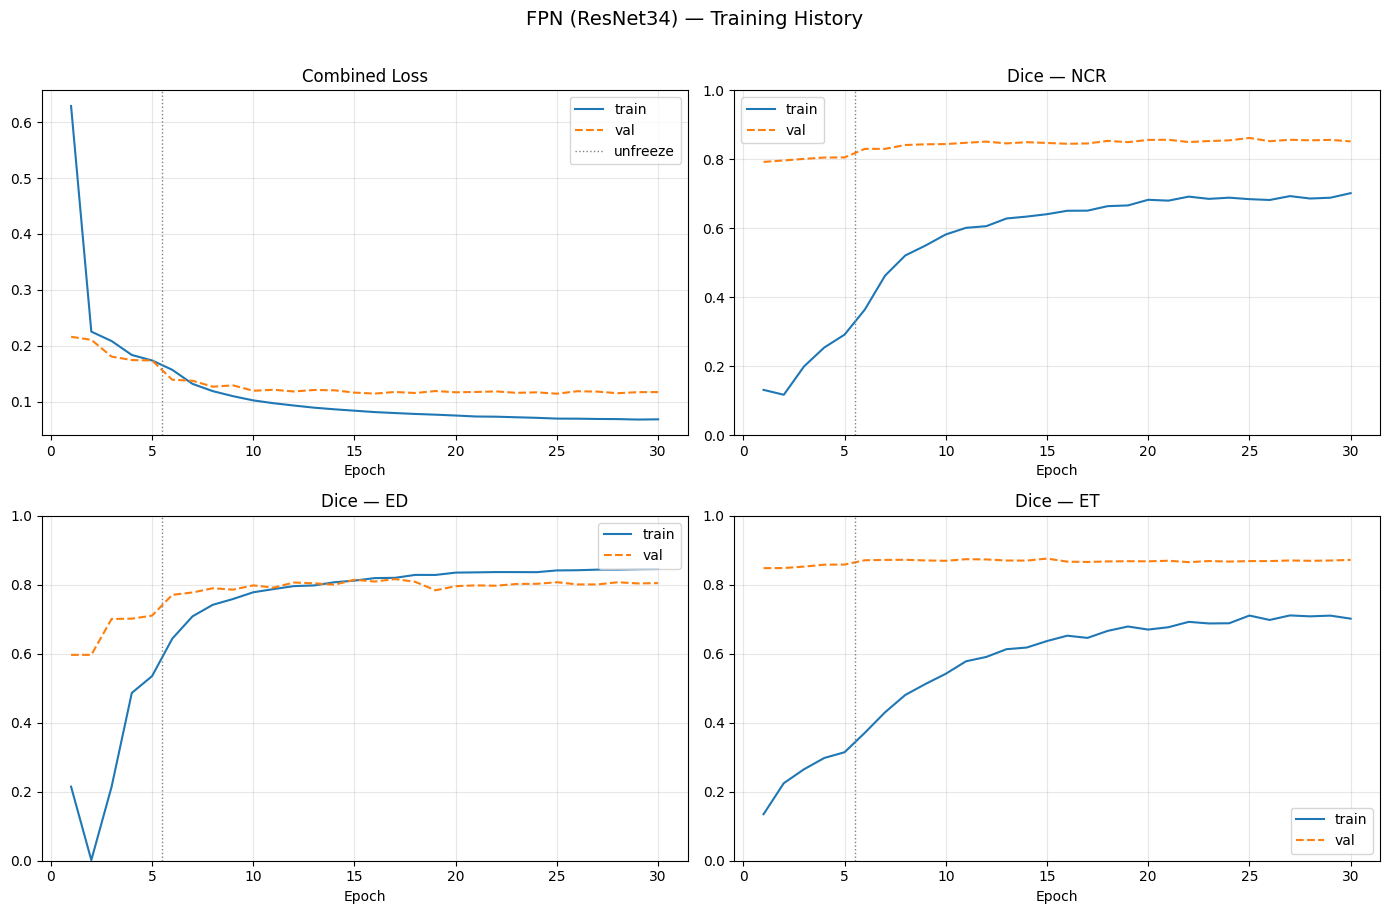

Saved -> EDA_02_outputs/fpn_training_curves.png


In [11]:
epochs = list(range(1, TOTAL_EPOCHS + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("FPN (ResNet34) — Training History", fontsize=14, y=1.01)

ax = axes[0, 0]
ax.plot(epochs, [m["loss"] for m in history["train"]], label="train")
ax.plot(epochs, [m["loss"] for m in history["val"]],   label="val",   linestyle="--")
ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1, label="unfreeze")
ax.set_title("Combined Loss")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

class_plot = [("dice_NCR", "NCR"), ("dice_ED", "ED"), ("dice_ET", "ET")]
for i, (key, label) in enumerate(class_plot):
    ax = axes[(i + 1) // 2, (i + 1) % 2]
    ax.plot(epochs, [m[key] for m in history["train"]], label="train")
    ax.plot(epochs, [m[key] for m in history["val"]],   label="val",   linestyle="--")
    ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Dice — {label}")
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_dir = PROJECT_ROOT / "training_outputs"
out_dir.mkdir(exist_ok=True)
fig.savefig(str(out_dir / "fpn_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> training_outputs/fpn_training_curves.png")

## 9 — Final evaluation on the test set (2D slice-level)

In [ ]:
ckpt = load_checkpoint(BEST_CKPT, model, device=DEVICE)
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

test_metrics = evaluate(    
    model, test_loader, criterion, DEVICE, crop_size=CROP_SIZE,
)

print("\n" + "=" * 50)
print("TEST SET RESULTS (2D slice-level)")
print("=" * 50)
for k, v in sorted(test_metrics.items()):
    print(f"  {k:<20s}: {v:.4f}")

fg_test = np.mean([test_metrics["dice_NCR"], test_metrics["dice_ED"], test_metrics["dice_ET"]])
print(f"\n  {'mean_fg_dice':<20s}: {fg_test:.4f}")

Loaded best checkpoint from epoch 15



TEST SET RESULTS (2D slice-level)
  dice_ED             : 0.8038
  dice_ET             : 0.8502
  dice_NCR            : 0.8297
  dice_background     : 0.9987
  dice_loss           : 0.1228
  focal_loss          : 0.0179
  loss                : 0.1407

  mean_fg_dice        : 0.8279


## 10 — Save training history

In [13]:
history_path = str(CKPT_DIR / "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"History saved -> {history_path}")

History saved -> C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\fpn\history.json
